# Residency Day 1: Advanced Data Mining Project - Deliverable 1

**Name:** Bikram Lamsal  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Title:** Data Collection, Cleaning, and Exploration  
**Date:** July 24, 2026

## Deliverable 1: Data Collection, Cleaning, and Exploration

This deliverable uses the UCI Online Retail dataset. The dataset is appropriate because it contains real transactional customer-purchase data with more than 500 records and 8 original attributes. It supports later regression, classification, clustering, and association-rule mining tasks.

The purpose of this first phase is to make the raw retail data trustworthy and understandable before modeling. Data mining results are only as reliable as the data preparation step. For that reason, this notebook focuses on inspection, validation, cleaning checks, feature creation, and exploratory visualizations. The cleaned sample used here was generated from the full cleaned dataset so that EDA remains reproducible and lightweight while still preserving the main transaction patterns.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

Matplotlib is building the font cache; this may take a moment.


In [2]:
data_path = Path("data/online_retail_cleaned_sample.csv")
df = pd.read_csv(data_path, parse_dates=["InvoiceDate"])
print(f"Sample rows used for EDA: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Sample rows used for EDA: 50,000
Columns: 12


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,InvoiceDayOfWeek,InvoiceHour
0,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047,United Kingdom,25.50,2010-12,Wednesday,8
1,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,2010-12-01 08:34:00,9.95,13047,United Kingdom,19.90,2010-12,Wednesday,8
2,536370,22540,MINI JIGSAW CIRCUS PARADE,24,2010-12-01 08:45:00,0.42,12583,France,10.08,2010-12,Wednesday,8
3,536373,82482,WOODEN PICTURE FRAME WHITE FINISH,6,2010-12-01 09:02:00,2.10,17850,United Kingdom,12.60,2010-12,Wednesday,9
4,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:32:00,2.55,17850,United Kingdom,15.30,2010-12,Wednesday,9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   InvoiceNo         50000 non-null  int64         
 1   StockCode         50000 non-null  object        
 2   Description       50000 non-null  object        
 3   Quantity          50000 non-null  int64         
 4   InvoiceDate       50000 non-null  datetime64[ns]
 5   UnitPrice         50000 non-null  float64       
 6   CustomerID        50000 non-null  int64         
 7   Country           50000 non-null  object        
 8   TotalPrice        50000 non-null  float64       
 9   InvoiceMonth      50000 non-null  object        
 10  InvoiceDayOfWeek  50000 non-null  object        
 11  InvoiceHour       50000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 4.6+ MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,50000.0,NaN,NaN,NaN,560593.09626,536367.0,549185.0,561882.0,572058.0,581587.0,13072.834664
StockCode,50000,3110,85123A,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,50000,3220,WHITE HANGING HEART T-LIGHT HOLDER,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,50000.0,NaN,NaN,NaN,12.6262,1.0,2.0,6.0,12.0,4800.0,42.9546
InvoiceDate,50000,NaN,NaN,NaN,2011-07-10 20:28:02.787600128,2010-12-01 08:34:00,2011-04-07 09:35:00,2011-07-31 12:52:00,2011-10-20 12:43:00,2011-12-09 12:50:00,NaN
UnitPrice,50000.0,NaN,NaN,NaN,3.136655,0.001,1.25,1.95,3.75,2500.0,16.63874
CustomerID,50000.0,NaN,NaN,NaN,15294.68748,12347.0,13952.0,15157.0,16809.0,18287.0,1716.79884
Country,50000,37,United Kingdom,44481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalPrice,50000.0,NaN,NaN,NaN,22.645147,0.001,4.95,12.48,19.8,38970.0,187.081769
InvoiceMonth,50000,13,2011-11,8041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary

,column,missing_count
0,InvoiceNo,0
1,StockCode,0
2,Description,0
3,Quantity,0
4,InvoiceDate,0
5,UnitPrice,0
6,CustomerID,0
7,Country,0
8,TotalPrice,0
9,InvoiceMonth,0


In [6]:
duplicate_count = df.duplicated().sum()
invalid_quantity = (df["Quantity"] <= 0).sum()
invalid_price = (df["UnitPrice"] <= 0).sum()
cleaning_checks = pd.DataFrame({
    "check": ["duplicate_rows", "non_positive_quantity", "non_positive_unit_price"],
    "count": [duplicate_count, invalid_quantity, invalid_price]
})
cleaning_checks

,check,count
0,duplicate_rows,0
1,non_positive_quantity,0
2,non_positive_unit_price,0


### Cleaning Interpretation

The raw Online Retail dataset originally included missing customer identifiers, cancelled invoices, duplicate rows, and invalid quantity or price values. Those records were removed before this notebook sample was created. The remaining rows have valid customer IDs, positive quantities, positive unit prices, and a calculated `TotalPrice` feature.

Each cleaning decision was tied to a later analytical need. Missing customer IDs would make customer segmentation unreliable. Cancelled invoices would mix returns with purchases and distort sales totals. Non-positive quantities or unit prices would create misleading revenue values. Duplicate rows would inflate product frequency, basket size, and invoice revenue. Cleaning these issues first reduces noise and makes the later regression, classification, clustering, and association-rule results more defensible.

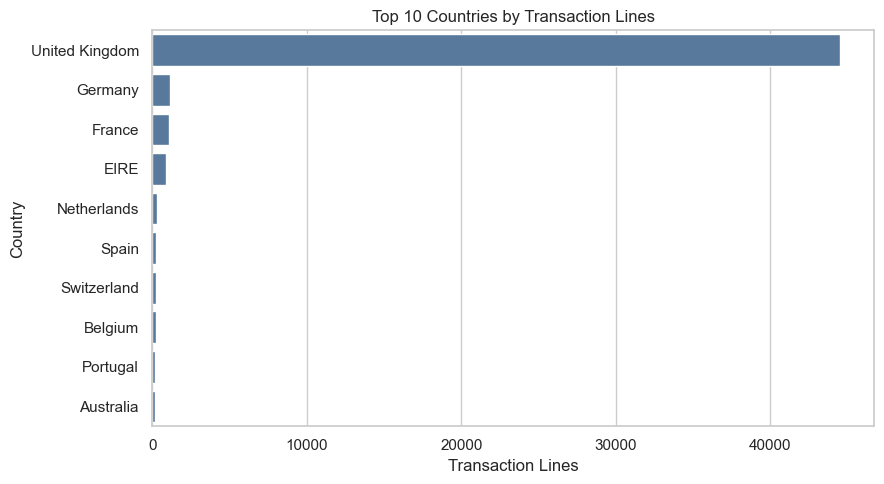

In [7]:
top_countries = df["Country"].value_counts().head(10).reset_index()
top_countries.columns = ["Country", "Transactions"]
sns.barplot(data=top_countries, y="Country", x="Transactions", color="#4C78A8")
plt.title("Top 10 Countries by Transaction Lines")
plt.xlabel("Transaction Lines")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Country Distribution Interpretation

The country chart is used to understand market concentration. Because the United Kingdom accounts for most transaction lines, country must be handled carefully in later modeling. It can provide predictive information, but it can also make models overly dependent on the dominant market. This is why later pipelines one-hot encode `Country` instead of treating it as a numeric field.

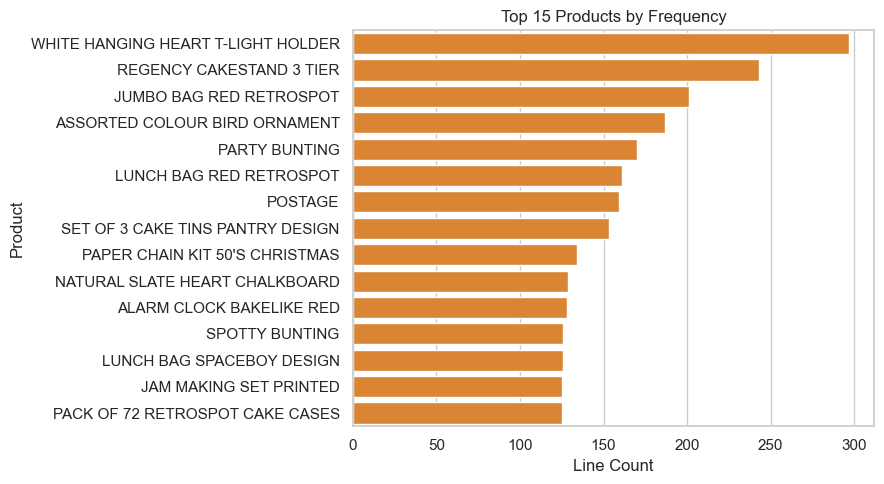

In [8]:
top_products = df["Description"].value_counts().head(15).reset_index()
top_products.columns = ["Description", "Count"]
sns.barplot(data=top_products, y="Description", x="Count", color="#F58518")
plt.title("Top 15 Products by Frequency")
plt.xlabel("Line Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Product Frequency Interpretation

The top-product chart helps identify products that drive repeated transaction activity. Frequent products are important because they influence both revenue patterns and association rule mining. If a product appears often, it has more opportunity to form frequent itemsets. However, frequency alone does not prove a strong relationship between items, which is why later association rules use lift in addition to support.

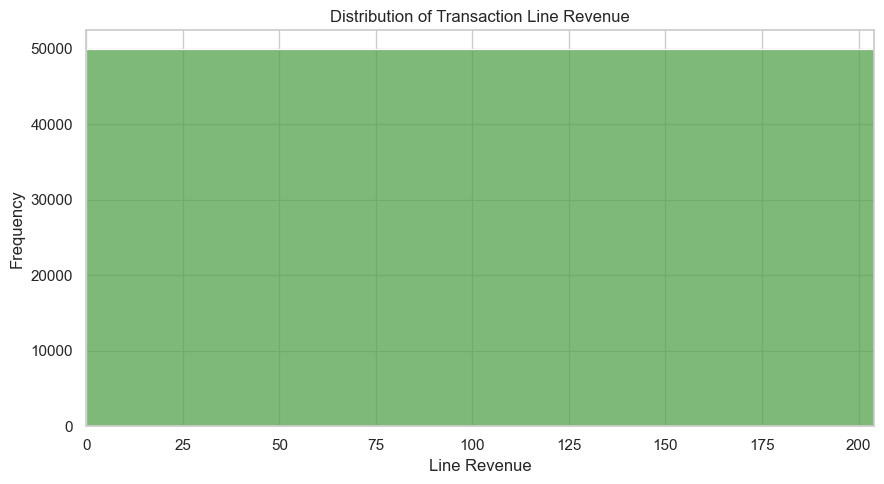

In [9]:
sns.histplot(df["TotalPrice"], bins=50, color="#54A24B")
plt.xlim(0, df["TotalPrice"].quantile(0.99))
plt.title("Distribution of Transaction Line Revenue")
plt.xlabel("Line Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Revenue Distribution Interpretation

The revenue histogram shows that transaction-line revenue is right-skewed. Most transaction lines have modest revenue values, while a smaller number of large transactions create a long tail. This insight guides later modeling decisions: invoice-level aggregation is more appropriate than individual line prediction, and log transformation helps stabilize extreme revenue values in regression.

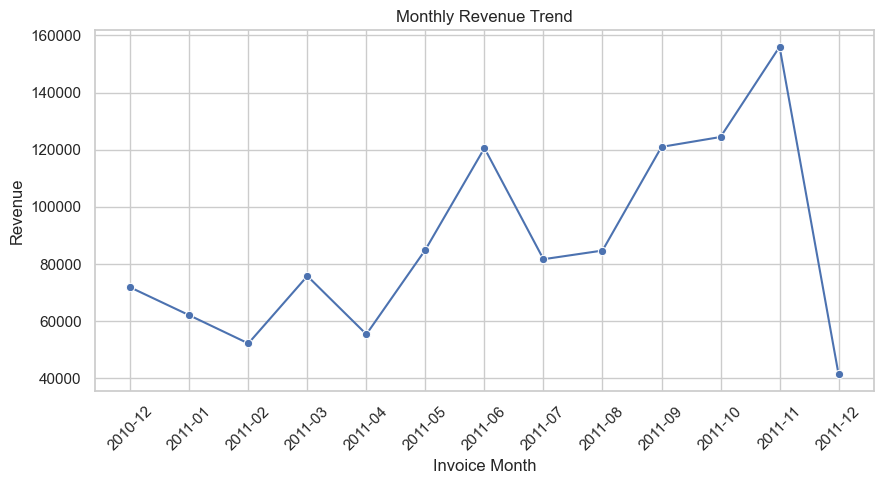

In [10]:
monthly_sales = df.groupby("InvoiceMonth", as_index=False)["TotalPrice"].sum()
sns.lineplot(data=monthly_sales, x="InvoiceMonth", y="TotalPrice", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Invoice Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Monthly Trend Interpretation

The monthly trend plot is included to check for seasonality and time-based sales patterns. Retail datasets often contain seasonal spikes, especially near holidays. Recognizing time effects helps justify adding calendar features such as invoice month, day of week, and invoice hour in later predictive models.

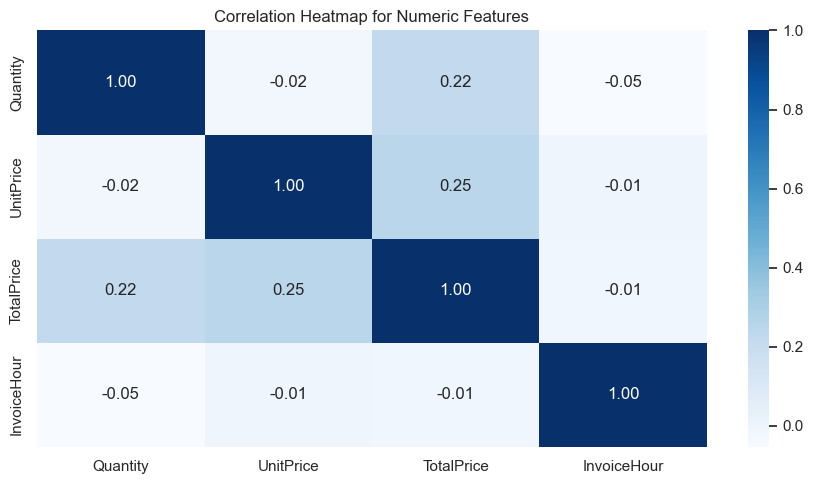

In [11]:
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice", "InvoiceHour"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.show()

### EDA Insights

The United Kingdom dominates the transaction volume, so country effects should be considered in later modeling. Frequent products are mostly small gift and household items, which suggests product popularity is concentrated in a set of repeat-purchased items. Revenue is right-skewed, meaning a small number of larger line items contribute heavily to sales. The monthly trend helps identify seasonality, while the correlation heatmap confirms that `Quantity` and `UnitPrice` influence `TotalPrice`, making engineered invoice-level features useful for regression and classification.

The main outcome of Deliverable 1 is a clear modeling direction. The project should not model raw transaction lines only; it should create invoice-level features for revenue prediction and high-value invoice classification, customer-level features for segmentation, and basket-level records for association rule mining. This separation of analytical views is important because each data mining method needs a dataset shaped around its specific question.